## Creating the map for overlap

#### Imports

In [1]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString, Polygon, Point, MultiPolygon
import numpy as np
import networkx as nx
from itertools import combinations
import osmnx as ox
import tobler

#### Pre-defined functions (made by us)

In [ ]:
## Initiat the all node pairs and generate a random number of people that travel between them
def generate_trip_weight(df, rangestart, rangestop):

    # Set a seed so we dont need to save the file locally
    random.seed(154)

    all_nodes = df["cell_id"].tolist()

    pairs = list(combinations(all_nodes, 2))

    o_list = []
    d_list = []
    weights_list = []
    o_p_list = []
    d_p_list = []

    for nodes in pairs:
        ## find the values from the created pairs
        w = random.randrange(rangestart, rangestop)
        o = nodes[0]
        d = nodes[1]

        o_row = df.loc[df['cell_id'].eq(o)]
        d_row = df.loc[df['cell_id'].eq(d)]

        o_point = o_row["geometry"].iloc[0] # For Jev, I just added the .iloc[0] at the ends to focus on the value
        d_point = d_row["geometry"].iloc[0] # For Jev, I just added the .iloc[0] at the ends to focus on the value
        
        ## Appending to their list for later population
        o_list.append(o)
        d_list.append(d)
        weights_list.append(w)
        o_p_list.append(o_point)
        d_p_list.append(d_point)


    pair_df = pd.DataFrame({
            "o": o_list,
            "d": d_list,
            "weight": weights_list,
            "o-point": o_p_list,
            "d-point": d_p_list
        })
    # Uncoment this to save pair combinations as dataframe
    #pair_df.to_csv("od_tabel") 
    
    return pair_df

## Sum the nodes total weight by all trips to said node

def create_weights(df, od_df):
    weighted_df = df.copy()
    weighted_df["weight"] = ""

    all_nodes = df["cell_id"].tolist()
    
    for unique_node in all_nodes:
        total_weight = 0
        #for index, row in od_df.iterrows():  ################# Changed this so it now goes through a dataframe instead of a a list of tuples ######
        #    if row["o"] == unique_node or row["d"] == unique_node: ##### Also changed this so the calling works for a DF
        #        total_weight += row["weight"] ###### Same here
        total_weight = od_df.loc[
                (od_df["o"] == unique_node) | (od_df["d"] == unique_node),
                "weight"
            ].sum() ## Optermized the iterrows() loop so it isnt as expensive any more

        weighted_df.loc[weighted_df["cell_id"] == unique_node, 'weight'] = total_weight

        weighted_df.to_csv("Hexagon_weighted_data")

    return weighted_df

def finding_neighbors(pointes_weighted, grid):
    weighted_grid = grid.copy()

    weighted_grid = weighted_grid.merge(
    pointes_weighted[['cell_id', 'weight']], on='cell_id', how='left')

    mytree = weighted_grid.sindex
    weighted_grid["vicinity"] = weighted_grid.apply(
        lambda x: weighted_grid.iloc[
            mytree.query(x.geometry, predicate="touches")
        ]["cell_id"].tolist(),
        axis=1
    )

    return weighted_grid

def Create_grid(res, prompt_1, proj_crs, prompt_2=False, prompt_3=False, return_points=False):

    # If prompt_2 is given, merge both geocoded areas into one polygon (for multi-area grids);
    # otherwise, use only prompt_1.
    if prompt_2:
        prompt_1_gdf = ox.geocode_to_gdf(prompt_1)
        prompt_2_gdf = ox.geocode_to_gdf(prompt_2)
        merged_geom = prompt_1_gdf.union_all().union(prompt_2_gdf.union_all())

    if prompt_3: # the problem was with extra tab
        prompt_3_gdf = ox.geocode_to_gdf(prompt_3)
        merged_geom = merged_geom.union(prompt_3_gdf.union_all())
            
        # back into GeoDataFrame
        merged = gpd.GeoDataFrame(
            {"name": ["merged_area"]},
            geometry=[merged_geom],
            crs=prompt_1_gdf.crs
            ).to_crs(proj_crs)
        
        my_polygon = merged.copy()
        
    else:
        my_polygon = ox.geocode_to_gdf(prompt_1).to_crs(proj_crs)
        
    # make bbox
    coords = my_polygon.get_coordinates()
    xmin=min(coords.x)
    xmax=max(coords.x)
    ymin=min(coords.y)
    ymax=max(coords.y)
    bbox = Polygon(
        [
        Point([xmin, ymin]),
        Point([xmax, ymin]),
        Point([xmax, ymax]),
        Point([xmin, ymax])
        ]
    )
    bbox = gpd.GeoDataFrame(
        {
            "geometry": [bbox]
        },
        crs = my_polygon.crs
    )

    # make grid
    grid = tobler.util.h3fy(
        source=bbox,
        resolution=res,
        clip=False,
        buffer=False,
        return_geoms=True
    )

    grid["hex_id"] = grid.index
    grid = grid.reset_index(drop=True)
    grid["cell_id"] = grid.index

    grid = grid.to_crs(proj_crs)
    
    # make sure both are in the same CRS
    # grid_copy = grid.to_crs(merged.crs)

    poly = my_polygon.union_all()

    # centroid of each hexagon
    grid["centroid"] = grid.geometry.centroid 

    # True/False: centroid lies inside polygon
    grid["centroid_inside"] = grid["centroid"].within(poly)

    # keep only hexagons whose centroid is inside
    grid_inside = grid[grid["centroid_inside"]].copy()
    
    # grid_inside = grid[grid.intersects(poly)].copy() ## THIS IS ANOTHER OPTION, INSTEAD OF CENTROIDS 
    
    # representative points (better than centroid for polygons) ## For JANUS, I added this part so we dont need to call another function to get points
    points = grid_inside.copy()
    points["geometry"] = points.representative_point()
    
    # IF you want to get points, you need to change the value of return_points to True when calling the function
    if return_points:
        return grid_inside, points, my_polygon
    else:
        return grid_inside

def remove_tiny_islands(geom, min_area):
    """
    Keep all polygons larger than min_area.
    Area is in CRS units squared, so use projected CRS in meters.
    Example: 200000 = 0.2 sq km if CRS is meters.
    """
    if geom.geom_type != "MultiPolygon":
        return geom

    kept = [part for part in geom.geoms if part.area >= min_area]

    if not kept:
        return geom
    if len(kept) == 1:
        return kept[0]
    return MultiPolygon(kept)

def Create_grid_1(res, prompt_1, proj_crs, prompt_2=False, prompt_3=False, return_points=False):
    # Start with prompt_1
    prompt_1_gdf = ox.geocode_to_gdf(prompt_1)
    merged_geom = prompt_1_gdf.union_all()

    # Add prompt_2 if provided
    if prompt_2:
        prompt_2_gdf = ox.geocode_to_gdf(prompt_2)
        merged_geom = merged_geom.union(prompt_2_gdf.union_all())

    # Add prompt_3 if provided
    if prompt_3:
        prompt_3_gdf = ox.geocode_to_gdf(prompt_3)
        merged_geom = merged_geom.union(prompt_3_gdf.union_all())

    # Back into GeoDataFrame and project
    merged = gpd.GeoDataFrame(
        {"name": ["merged_area"]},
        geometry=[merged_geom],
        crs=prompt_1_gdf.crs
    ).to_crs(proj_crs)

    # Use projected geometry from here
    geom = merged.geometry.iloc[0]

    # Keep only the largest area
    if isinstance(geom, MultiPolygon):
        geom = remove_tiny_islands(geom, min_area=20000000)

    my_polygon = gpd.GeoDataFrame(
        {"name": ["merged_area"]},
        geometry=[geom],
        crs=proj_crs
    )

    # make bbox
    coords = my_polygon.get_coordinates()
    xmin = min(coords.x)
    xmax = max(coords.x)
    ymin = min(coords.y)
    ymax = max(coords.y)

    bbox = Polygon([
        Point([xmin, ymin]),
        Point([xmax, ymin]),
        Point([xmax, ymax]),
        Point([xmin, ymax])
    ])

    bbox = gpd.GeoDataFrame({"geometry": [bbox]}, crs=my_polygon.crs)

    # make grid
    grid = tobler.util.h3fy(
        source=bbox,
        resolution=res,
        clip=False,
        buffer=False,
        return_geoms=True
    )

    grid["hex_id"] = grid.index
    grid = grid.reset_index(drop=True)
    grid["cell_id"] = grid.index
    grid = grid.to_crs(proj_crs)

    poly = my_polygon.union_all()

    # centroid of each hexagon
    grid["centroid"] = grid.geometry.centroid

    # True/False: centroid lies inside polygon
    grid["centroid_inside"] = grid["centroid"].within(poly)

    # keep only hexagons whose centroid is inside
    grid_inside = grid[grid["centroid_inside"]].copy()

    # representative points
    points = grid_inside.copy()
    points["geometry"] = points.representative_point()

    if return_points:
        return grid_inside, points, my_polygon
    else:
        return grid_inside
    
def clean_postal_codes(path):
    file_path = Path(path)
    rows = []

    with open(file_path, "r", encoding="latin1") as f:
        next(f)  # skip header

        for line in f:
            parts = [p.strip().strip('"') for p in line.split(",")]

            if len(parts) >= 4:
                postcode_text = parts[2]
                population_text = parts[-1] # this has to -1 as some line are longer than others and the seperator i a comma

                if postcode_text[:4].isdigit():
                    rows.append({
                        "postal_code": postcode_text[:4],
                        "population": population_text
                    })

    pop_df = pd.DataFrame(rows)

    pop_df["postal_code"] = pop_df["postal_code"].astype(str).str.zfill(4)
    pop_df["population"] = pd.to_numeric(pop_df["population"], errors="coerce")

    pop_df = pop_df.dropna(subset=["postal_code", "population"])

    print(pop_df.head())
    print(pop_df.shape)

    return pop_df

def keep_largest_polygon(geom):
    if isinstance(geom, MultiPolygon):
        return max(geom.geoms, key=lambda g: g.area)
    return geom

def cal_score(G, od_df):
    temp_score = 0
    pairs = list(combinations(G.nodes(), 2))
    total_demand = od_df["weight"].sum()
    for (node1, node2) in pairs:
        pair_demand = od_df.loc[
            ((od_df["o"] == node1) | (od_df["d"] == node1)) & ((od_df["o"] == node2) | (od_df["d"] == node2)),
            "weight"
        ].sum()
        temp_score += pair_demand

    evaluation_score = (temp_score / total_demand) * 100

    return evaluation_score

#### Learn this one more confidently for exam

In [3]:
def allocate_population_to_hexagons(grid, postal_gdf, population_df,
                                    postal_code_col="postnummer",
                                    population_code_col="postal_code",
                                    population_col="population"):
    """
    Allocate postal-code population to hexagons by area overlap.

    Each hexagon gets:
        sum((intersection_area / postal_area) * postal_population)

    Parameters
    ----------
    grid : GeoDataFrame
        Hexagon polygons. Must contain 'cell_id'.
    postal_gdf : GeoDataFrame
        Postal code boundary polygons.
    population_df : DataFrame
        DataFrame with postal code and population.
    postal_code_col : str
        Column in postal_gdf with postal code.
    population_code_col : str
        Column in population_df with postal code.
    population_col : str
        Column in population_df with population.

    Returns
    -------
    grid_with_pop : GeoDataFrame
        Grid with a new column 'hex_population'.
    intersections : GeoDataFrame
        Intersection table for debugging/inspection.
    """

    # Copy so original objects are untouched
    grid = grid.copy()
    postal_gdf = postal_gdf.copy()
    population_df = population_df.copy()

    # Make sure postal-code columns have same type
    grid["cell_id"] = grid["cell_id"].astype(int)
    postal_gdf[postal_code_col] = postal_gdf[postal_code_col].astype(str)
    population_df[population_code_col] = population_df[population_code_col].astype(str)

    # Clean population column
    population_df[population_col] = pd.to_numeric(population_df[population_col], errors="coerce").fillna(0)

    # Merge population into postal polygons
    postal_gdf = postal_gdf.merge(
        population_df[[population_code_col, population_col]],
        left_on=postal_code_col,
        right_on=population_code_col,
        how="left"
    )

    postal_gdf[population_col] = postal_gdf[population_col].fillna(0)

    # Reproject postal polygons to same CRS as grid
    if postal_gdf.crs != grid.crs:
        postal_gdf = postal_gdf.to_crs(grid.crs)

    # Keep only polygons that intersect the grid area
    postal_gdf = postal_gdf[postal_gdf.intersects(grid.union_all())].copy()

    # Calculate total area of each postal polygon
    postal_gdf["postal_area"] = postal_gdf.geometry.area

    # Overlay = intersections between hexagons and postal code polygons
    intersections = gpd.overlay(
        grid[["cell_id", "geometry"]],
        postal_gdf[[postal_code_col, population_col, "postal_area", "geometry"]],
        how="intersection"
    )

    # Area of intersection
    intersections["intersection_area"] = intersections.geometry.area

    # Share of each postal code that lies inside each hexagon
    intersections["postal_share_in_hex"] = (
        intersections["intersection_area"] / intersections["postal_area"]
    )

    # Population contributed from postal code to hexagon
    intersections["pop_contribution"] = (
        intersections["postal_share_in_hex"] * intersections[population_col]
    )

    # Sum all postal-code contributions per hexagon
    hex_pop = (
        intersections.groupby("cell_id", as_index=False)["pop_contribution"]
        .sum()
        .rename(columns={"pop_contribution": "hex_population"})
    )

    # Attach to grid
    grid_with_pop = grid.merge(hex_pop, on="cell_id", how="left")
    grid_with_pop["hex_population"] = grid_with_pop["hex_population"].fillna(0)

    return grid_with_pop, intersections

## Initiat the all node pairs and generate a random number of people that travel between them
def generate_trip_weight_V2(df, population_col="weight", seed=154):

    # Set a seed so results are reproducible
    random.seed(seed)

    all_nodes = df["cell_id"].tolist()
    pairs = list(combinations(all_nodes, 2))

    o_list = []
    d_list = []
    weights_list = []
    o_p_list = []
    d_p_list = []

    for nodes in pairs:
        o = nodes[0]
        d = nodes[1]

        o_row = df.loc[df["cell_id"].eq(o)]
        d_row = df.loc[df["cell_id"].eq(d)]

        o_point = o_row["geometry"].iloc[0]
        d_point = d_row["geometry"].iloc[0]

        pop_o = float(o_row[population_col].iloc[0])
        pop_d = float(d_row[population_col].iloc[0])

        max_w = pop_o + pop_d

        # Random weight between 0 and sum of origin+destination population
        if max_w <= 0:
            w = 0.0
        else:
            w = random.uniform(0, max_w)

        o_list.append(o)
        d_list.append(d)
        weights_list.append(w)
        o_p_list.append(o_point)
        d_p_list.append(d_point)

    pair_df = pd.DataFrame({
        "o": o_list,
        "d": d_list,
        "weight": weights_list,
        "o-point": o_p_list,
        "d-point": d_p_list
    })

    return pair_df

### Parameters for creating the map of copenhagen

In [4]:
# parameters of grid
resolution = 8
prompt = "Copenhagen Municipality, Denmark" 
proj_crs = "EPSG:2062"
prompt_2 = "Frederiksberg Municipality, Denmark" 

prompt_3 = "Tårnby Municipality, Denmark"

#### Run the code with the parameters so the properly map is used

In [5]:
grid, points, my_polygon = Create_grid_1(resolution, prompt, proj_crs, prompt_2, prompt_3, return_points=True)

# Load postal-code boundaries
postal_gdf = gpd.read_file(
    "../data/Postal_code_data/"
    "86249533323639c4792ccbd48b0d9449f543d83f9e5a2f612a7ae700bb08c9ac/"
    "wgs84_geojson/postnummerinddeling.geojson"
)

# Load the populations based on postal codes
pop_df = clean_postal_codes(
    "../data/Postal_code_data/20264139490617746621POSTNR139926258718.csv"
)

# Make sure postal-code field is same format
postal_gdf["postnummer"] = postal_gdf["postnummer"].astype(str)
pop_df["postal_code"] = pop_df["postal_code"].astype(str)

/home/jspe/venvs/Bachelor_project/lib/python3.11/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


  postal_code  population
0        1050          23
1        1051         412
2        1052         425
3        1053         416
4        1054         382
(1063, 2)


#### Merge the datasets so the population data is on the hexagons

In [6]:
grid_with_pop, postal_hex_intersections = allocate_population_to_hexagons(
    grid=grid,
    postal_gdf=postal_gdf,
    population_df=pop_df,
    postal_code_col="postnummer",
    population_code_col="postal_code",
    population_col="population"
)

pointes_weighted = points.merge(
    grid_with_pop[["cell_id", "hex_population"]],
    on="cell_id",
    how="left"
)

pointes_weighted["hex_population"] = pointes_weighted["hex_population"].fillna(0)
pointes_weighted["weight"] = pointes_weighted["hex_population"]

#### Create the OD dataset based on the map

In [ ]:
## creating the pair list and weight for each node based on the trips taken from and to each node/station
od_df = generate_trip_weight_V2(pointes_weighted, population_col="weight", seed=154)

## Finding the surrounding/connecting hexagons to each hexagon
valid_connections = finding_neighbors(pointes_weighted, grid)

## Finding total system demand
total_demand = od_df["weight"].sum()

### Visulise the data at this point

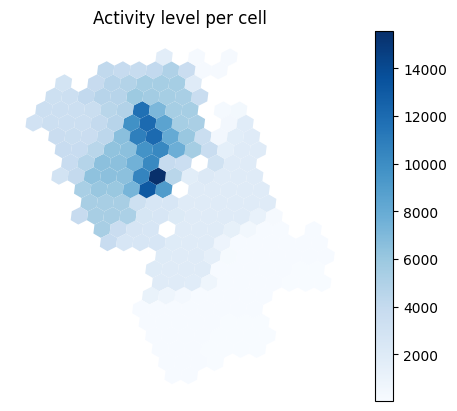

In [8]:
grid_heatmap = grid.merge(
    pointes_weighted[["cell_id", "weight"]],
    on="cell_id",
    how="left"
)

grid_heatmap["weight_int"] = grid_heatmap["weight"].astype(int)

fig, ax = plt.subplots(1,1)
grid_heatmap.plot(
    ax=ax,
    column="weight_int",
    cmap = "Blues",
    legend=True
)
ax.set_axis_off()
ax.set_title("Activity level per cell");

## Find the already exisitng metro stops relevant hexagons

### Preproccesing steps to only use the metro lines

In [9]:
# imports
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import contextily as cx

#### Load in the correct files from the GTFS data

In [11]:
GTFS_PATH = Path("../data/raw/GTFS_Copenhagen.zip")

if not GTFS_PATH.exists():
    raise FileNotFoundError(
        "GTFS ZIP not found. Download it as described in README.md"
    )

# List the files in the GTFS ZIP
with zipfile.ZipFile(GTFS_PATH, "r") as z:
    names = z.namelist()
    print("Number of files in zip:", len(names))

with zipfile.ZipFile(GTFS_PATH, "r") as z:
    stops = pd.read_csv(z.open("GTFS_Copenhagen/stops.txt"))

Number of files in zip: 12


#### Clean for only the metro stops

In [12]:
# stops filtering for metro only
metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]

# remove the line based on stop_id
metro_stops = metro_stops[metro_stops["stop_id"] != 821004401]

/tmp/ipykernel_445828/1801734949.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]


#### Transitioning it to geopandas format

In [13]:
# Stops GeoDataFrame (WGS84)
gdf_stops = gpd.GeoDataFrame(
    metro_stops,
    geometry=gpd.points_from_xy(metro_stops.stop_lon, metro_stops.stop_lat),
    crs="EPSG:4326"
)

gdf_stops_3857 = gdf_stops.to_crs(grid.crs)

#### Plot the data on the Copenhagen map

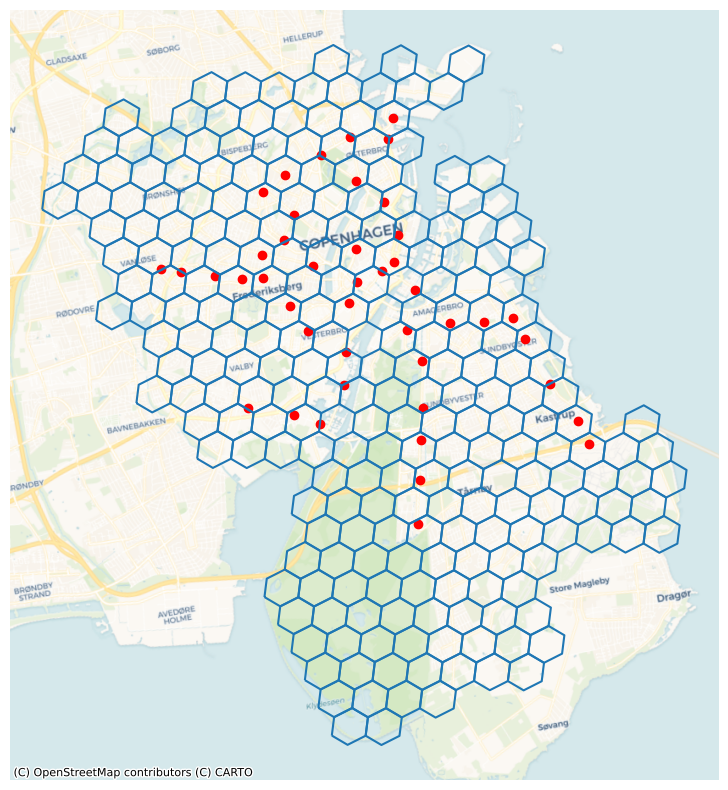

In [36]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf_stops_3857[gdf_stops_3857['location_type'] == 0].plot(ax=ax, 
                                       color='red') 

grid.boundary.plot(ax=ax)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs = grid.crs)
ax.set_axis_off()
plt.show()

### Connect the metro staions to the hexagon they are located in

In [31]:
grid_centroids = grid.copy()
grid_centroids = grid_centroids.set_geometry("centroid")

df_points = gdf_stops_3857.sjoin_nearest(
    grid_centroids,
    how="left",
    distance_col="dist_to_centroid"
)

In [53]:
stations = list(df_points["stop_name"])

/tmp/ipykernel_445828/2459009512.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


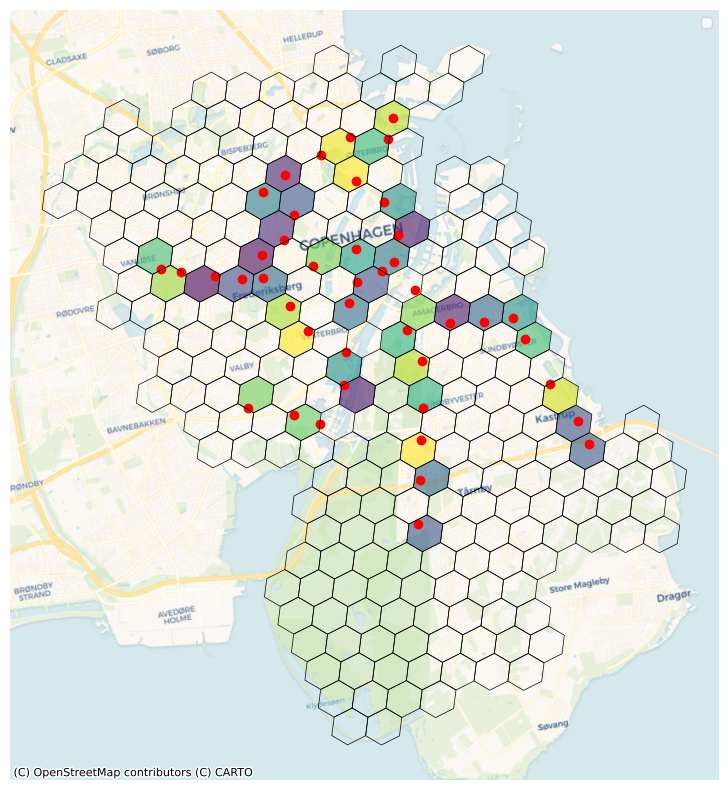

In [51]:
fig, ax = plt.subplots(figsize=(10, 10))

# cells matched to your 44 stops
matched_cells = grid[grid["cell_id"].isin(df_points["cell_id"])]

# plot selected cells filled
matched_cells.plot(ax=ax, column="cell_id", alpha=0.6, legend=False)

gdf_stops_3857[gdf_stops_3857['location_type'] == 0].plot(ax=ax, 
                                       color='red') 

# plot all grid boundaries
grid.boundary.plot(ax=ax, color="black", linewidth=0.5)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs=grid.crs)

ax.set_axis_off()
ax.legend()
plt.show()

#### Predefine the four metro lines

In [61]:
M1 = ["Vanløse St. (Metro)", "Flintholm St. (Metro)", "Lindevang St. (Metro)", "Fasanvej St. (Metro)", "Frederiksberg St. (Metro)", "Forum St. (Metro)", "Nørreport St. (Metro)", "Kongens Nytorv St. (Metro)", "Christianshavn St. (Metro)", "Islands Brygge St. (Metro)", "DR Byen St. (Metro)", "Sundby St. (Metro)", "Bella Center St. (Metro)", "Ørestad St. (Metro)", "Vestamager St. (Metro)"]
M2 = ["Vanløse St. (Metro)", "Flintholm St. (Metro)", "Lindevang St. (Metro)", "Fasanvej St. (Metro)", "Frederiksberg St. (Metro)", "Forum St. (Metro)", "Nørreport St. (Metro)", "Kongens Nytorv St. (Metro)", "Christianshavn St. (Metro)", "Islands Brygge St. (Metro)", "Amagerbro St. (Metro)", "Lergravsparken St. (Metro)", "Øresund St. (Metro)", "Amager Strand St. (Metro)", "Femøren St. (Metro)", "Kastrup St. (Metro)", "Københavns Lufthavn St. (Metro)"]
M3 = ["København H (Metro)", "Rådhuspladsen St. (Metro)", "Gammel Strand St. (Metro)", "Kongens Nytorv St. (Metro)", "Marmorkirken St. (Metro)", "Østerport St. (Metro)", "Trianglen St. (Metro)", "Poul Henningsens Plads St. (Metro)", "Vibenshus Runddel St. (Metro)", "Skjolds Plads St. (Metro)", "Nørrebro St. (Metro)", "Nørrebros Runddel St. (Metro)", "Nuuks Plads St. (Metro)", "Aksel Møllers Have St. (Metro)", "Frederiksberg St. (Metro)", "Frederiksberg Allé St. (Metro)", "Enghave Plads St. (Metro)", "København H (Metro)"]
M4 = ["Orientkaj St. (Metro)", "Nordhavn St. (Metro)", "Østerport St. (Metro)", "Marmorkirken St. (Metro)", "Kongens Nytorv St. (Metro)", "Gammel Strand St. (Metro)", "Rådhuspladsen St. (Metro)", "København H (Metro)", "Havneholmen St. (Metro)", "Enghave Brygge St. (Metro)", "Sluseholmen St. (Metro)", "Mozarts Plads St. (Metro)", "København Syd St. (Metro)"]

In [62]:
# Create mapping from station name to cell_id
name_to_cell_id = dict(zip(df_points['stop_name'], df_points['cell_id']))

# Create cell_id versions of the metro lines
M1_cell_ids = [name_to_cell_id[name] for name in M1]
M2_cell_ids = [name_to_cell_id[name] for name in M2]
M3_cell_ids = [name_to_cell_id[name] for name in M3]
M4_cell_ids = [name_to_cell_id[name] for name in M4]

In [63]:
G_metro = nx.Graph()
G_metro.add_nodes_from(df_points["cell_id"])
G_metro.add_edges_from([(M1_cell_ids[i], M1_cell_ids[i+1]) for i in range(len(M1_cell_ids)-1)])
G_metro.add_edges_from([(M2_cell_ids[i], M2_cell_ids[i+1]) for i in range(len(M2_cell_ids)-1)])
G_metro.add_edges_from([(M3_cell_ids[i], M3_cell_ids[i+1]) for i in range(len(M3_cell_ids)-1)])
G_metro.add_edges_from([(M4_cell_ids[i], M4_cell_ids[i+1]) for i in range(len(M4_cell_ids)-1)])

/tmp/ipykernel_445828/2178348054.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


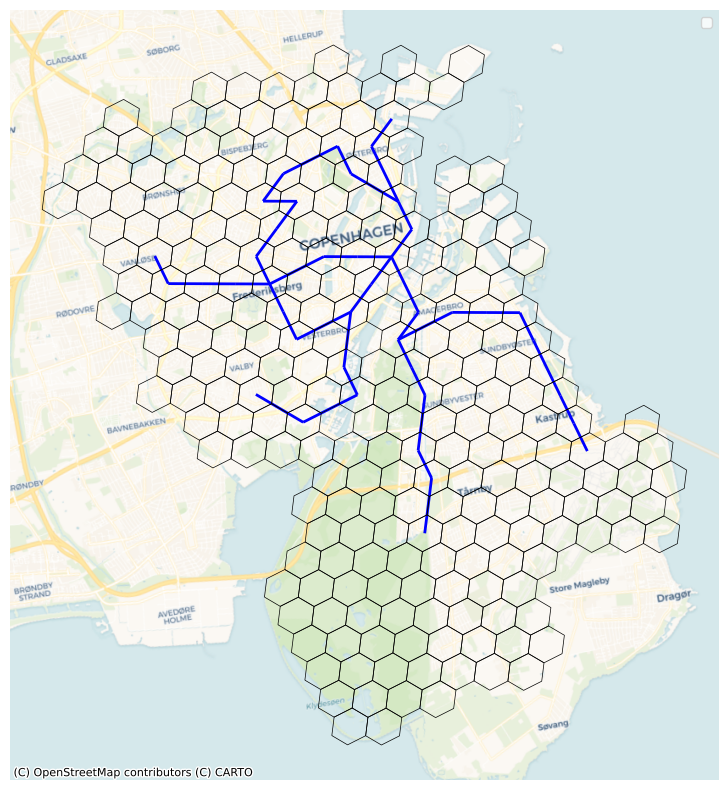

In [66]:
fig, ax = plt.subplots(figsize=(10, 10))

G_metro_edges = list(G_metro.edges())
edge_lines = []
for edge in G_metro_edges:
    cell_id_1, cell_id_2 = edge
    point_1 = grid.loc[grid["cell_id"] == cell_id_1, "centroid"].iloc[0]
    point_2 = grid.loc[grid["cell_id"] == cell_id_2, "centroid"].iloc[0]
    edge_lines.append(LineString([point_1, point_2]))

# build the visualisation from the G_metro and the grid
edge_gdf = gpd.GeoDataFrame(geometry=edge_lines, crs=grid.crs)
edge_gdf.plot(ax=ax, color="blue", linewidth=2)

# plot all grid boundaries
grid.boundary.plot(ax=ax, color="black", linewidth=0.5)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs=grid.crs)

ax.set_axis_off()
ax.legend()
plt.show()

In [ ]:
score = cal_score(G_metro, od_df)
score

np.float64(4.661360274814676)

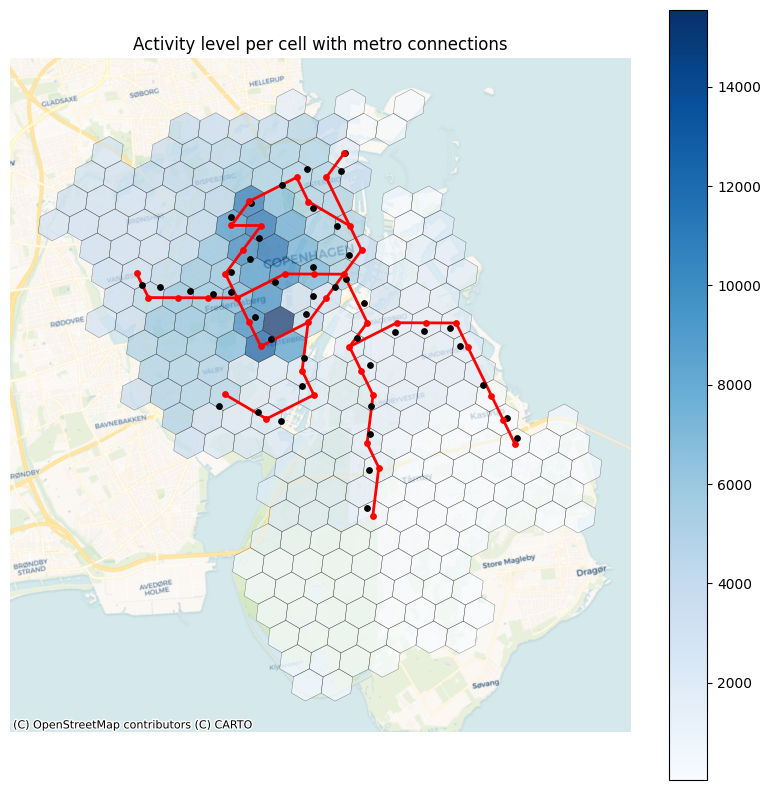

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString
import contextily as cx

# Merge weights into grid
grid_heatmap = grid.merge(
    pointes_weighted[["cell_id", "weight"]],
    on="cell_id",
    how="left"
)

# Fill missing weights if needed, then convert
grid_heatmap["weight"] = grid_heatmap["weight"].fillna(0)
grid_heatmap["weight_int"] = grid_heatmap["weight"].astype(int)

# Create metro edge lines
G_metro_edges = list(G_metro.edges())
edge_lines = []

for edge in G_metro_edges:
    cell_id_1, cell_id_2 = edge
    point_1 = grid.loc[grid["cell_id"] == cell_id_1, "centroid"].iloc[0]
    point_2 = grid.loc[grid["cell_id"] == cell_id_2, "centroid"].iloc[0]
    edge_lines.append(LineString([point_1, point_2]))

edge_gdf = gpd.GeoDataFrame(geometry=edge_lines, crs=grid.crs)

# Plot everything together
fig, ax = plt.subplots(figsize=(10, 10))

# Heatmap layer
grid_heatmap.plot(
    ax=ax,
    column="weight_int",
    cmap="Blues",
    legend=True,
    alpha=0.7,
    edgecolor="none"
)

# Metro lines on top
edge_gdf.plot(
    ax=ax,
    color="red",
    linewidth=2,
    zorder=3
)

# Optional: grid boundaries
grid.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.3,
    alpha=0.5,
    zorder=2
)

# Add the station nodes on top of everything
gdf_stops_3857[gdf_stops_3857['location_type'] == 0].plot(
    ax=ax,
    color='black',
    markersize=15,
    zorder=4,
    label="Metro Stations"
)

# Add the centroids of hexagons with a stations assosciated with them in the visualisation
grid_centroids[grid_centroids["cell_id"].isin(df_points["cell_id"])].plot(
    ax=ax,
    color='red',
    markersize=15,
    zorder=5,
    label="Hexagons with Metro Stations"
)

# Basemap underneath everything
cx.add_basemap(
    ax=ax,
    source=cx.providers.CartoDB.Voyager,
    crs=grid.crs,
    zoom='auto'
)

ax.set_axis_off()
ax.set_title("Activity level per cell with metro connections")
plt.show()

## Now we run the GA

#### Set the parameters

In [ ]:
# Parameters of GA algorithms
max_routes = 2
max_stops = 9
min_stops = 1

total_kids = 10

In [ ]:
accepted_kids = []

while len(accepted_kids) < total_kids:
    all_routes = {}
    potential_start = list(G_metro.nodes())

    routes = 1

    edge_list = {}

    while routes < max_routes + 1:
        if not potential_start:
            break

        route_current = []
        start_node = random.choice(potential_start)
        route_current.append(start_node)

        while len(route_current) < max_stops:

            ## can add a condition here to break randmoly so the routes dont always have the max number of stops, but it can be between min and max
            #if random.random() < 0.1:  # 10% chance to break
            #    break

            curr_node = route_current[-1]

            if curr_node in potential_start:
                potential_start.remove(curr_node)

            # filter out nodes already in this route
            vicinity_current = valid_connections.loc[valid_connections.cell_id==curr_node, "vicinity"].values[0]
            poss_neighbors = [n for n in vicinity_current if n not in route_current]

            # dead-end handling
            if not poss_neighbors:
                if len(route_current) < min_stops:
                    route_current.reverse()
                    curr_node = route_current[-1]
                    vicinity_current = valid_connections.loc[valid_connections.cell_id==curr_node, "vicinity"].values[0]
                    poss_neighbors = [n for n in vicinity_current if n not in route_current]
                    if not poss_neighbors:
                        break
                else:
                    break


            neighbor_node = []
            neighbor_weights = []
        
            for i in poss_neighbors:
                neighbor_node.append(i)
                neighbor_weights.append(valid_connections.loc[valid_connections["cell_id"] == i, "weight"].iloc[0])

            next_node = random.choices(neighbor_node, weights=neighbor_weights, k=1)[0]

            route_current.append(next_node)

            if curr_node in edge_list:
                edge_list[curr_node].append(next_node)
            else:
                edge_list[curr_node] = [next_node]

        all_routes[routes] = route_current
        routes += 1

    ## Check if its one componet 
    G = nx.from_dict_of_lists(edge_list)
    is_one_component = nx.is_connected(G)
    ############################################# This section Anastassia #############################################
    if is_one_component:
        evaluation_score = 0
        temp_score = 0
        pairs = list(combinations(G.nodes(), 2))
        for (node1, node2) in pairs:
            pair_demand = od_df.loc[
                ((od_df["o"] == node1) | (od_df["d"] == node1)) & ((od_df["o"] == node2) | (od_df["d"] == node2)),
                "weight"
            ].sum()
            temp_score += pair_demand

        evaluation_score = (temp_score / total_demand) * 100
    ###################################################################################################################

        all_routes["Score as %"] = evaluation_score
        all_routes["Number of edges"] = G.number_of_edges()
        accepted_kids.append(all_routes)
    else:
        continue